# Ejercicio 4: Analisis exploratorio con DuckDB

Cada consulta vive en `sql/ejercicio4/` y se ejecuta con DuckDB directamente sobre los Parquet de `data/raw/`.
`00_vistas.sql` define tres vistas (`viajes`, `viajes_validos` y `zonas`) que el resto de consultas reutiliza; ninguna materializa datos.

Las preguntas, la justificacion de cada una, la interpretacion de los resultados y los hallazgos estan en `docs/ejercicio4.md`.

In [1]:
import os
from pathlib import Path

import duckdb
import matplotlib.pyplot as plt
import pandas as pd

# Las rutas de los .sql y de los datos son relativas a la raiz del proyecto
if Path.cwd().name == "notebooks":
    os.chdir(Path.cwd().parent)

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
DIR_SQL = Path("sql/ejercicio4")

con = duckdb.connect()
con.execute((DIR_SQL / "00_vistas.sql").read_text())


def ejecutar(nombre: str) -> pd.DataFrame:
    consulta = (DIR_SQL / f"{nombre}.sql").read_text()
    print(consulta)
    return con.sql(consulta).df()


# Estilo de las graficas: un color fijo por tipo de taxi, ejes y rejilla discretos
COLORES = {"yellow": "#eda100", "green": "#008300"}
plt.rcParams.update({
    "figure.facecolor": "#fcfcfb", "axes.facecolor": "#fcfcfb",
    "axes.edgecolor": "#c3c2b7", "axes.labelcolor": "#52514e",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "axes.axisbelow": True, "grid.color": "#e1e0d9", "grid.linewidth": 0.6,
    "xtick.color": "#898781", "ytick.color": "#898781",
    "text.color": "#0b0b0b", "axes.titlesize": 12, "axes.titleweight": "bold",
    "axes.titlelocation": "left", "lines.linewidth": 2, "figure.dpi": 110,
})

In [2]:
# Vistas disponibles y tamano del conjunto analizado
con.sql("""
    SELECT tipo, count(*) AS registros,
           count(*) FILTER (WHERE ok_fecha AND ok_duracion AND ok_distancia AND ok_monto) AS validos,
           min(mes_archivo) AS primer_mes, max(mes_archivo) AS ultimo_mes
    FROM viajes GROUP BY tipo ORDER BY tipo
""").df()

,tipo,registros,validos,primer_mes,ultimo_mes
0,green,337114,324161,2026-01,2026-08
1,yellow,29703355,28603548,2026-01,2026-08


## 1. Comportamiento temporal

### P1. Como evoluciona la demanda mes a mes?

In [3]:
df_mes = ejecutar("01_viajes_por_mes")
df_mes

-- P1. Evolucion mensual de la demanda y los ingresos por tipo de taxi
SELECT tipo, anio, mes,
       count(*) AS viajes,
       round(count(*) / day(last_day(make_date(anio, mes, 1))), 0) AS viajes_por_dia,
       round(sum(total_amount) / 1e6, 2) AS ingresos_musd,
       round(avg(total_amount), 2) AS total_promedio
FROM viajes_validos
GROUP BY tipo, anio, mes
ORDER BY tipo, anio, mes;



,tipo,anio,mes,viajes,viajes_por_dia,ingresos_musd,total_promedio
0,green,2026,1,38882,1254.0,0.95,24.31
1,green,2026,2,35899,1282.0,0.88,24.39
2,green,2026,3,42677,1377.0,1.07,25.04
3,green,2026,4,42538,1418.0,1.09,25.51
4,green,2026,5,43277,1396.0,1.12,25.87
5,green,2026,6,42575,1419.0,1.12,26.24
6,green,2026,7,39511,1275.0,1.04,26.28
7,green,2026,8,38802,1252.0,1.03,26.51
8,yellow,2026,1,3561887,114900.0,105.50,29.62
9,yellow,2026,2,3251330,116119.0,98.85,30.40


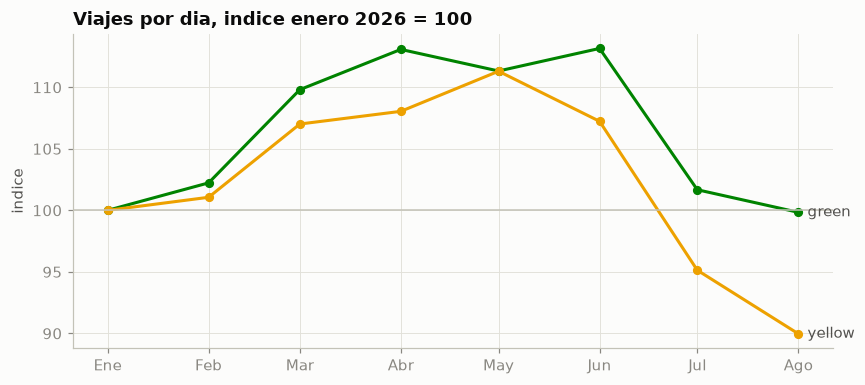

In [4]:
# Viajes por dia indexados a enero = 100: yellow y green tienen escalas 100 veces distintas
idx = df_mes.assign(
    periodo=pd.to_datetime(dict(year=df_mes.anio, month=df_mes.mes, day=1)),
    indice=df_mes.groupby("tipo").viajes_por_dia.transform(lambda s: 100 * s / s.iloc[0]),
)
fig, ax = plt.subplots(figsize=(8, 3.6))
for tipo, g in idx.groupby("tipo"):
    ax.plot(g.periodo, g.indice, color=COLORES[tipo], marker="o", markersize=5)
    ax.annotate(tipo, (g.periodo.iloc[-1], g.indice.iloc[-1]), xytext=(6, 0),
                textcoords="offset points", va="center", color="#52514e")
ax.axhline(100, color="#c3c2b7", linewidth=1)
ax.set_title("Viajes por dia, indice enero 2026 = 100")
ax.set_ylabel("indice")
MESES = ["Ene", "Feb", "Mar", "Abr", "May", "Jun", "Jul", "Ago", "Sep", "Oct", "Nov", "Dic"]
periodos = sorted(idx.periodo.unique())
ax.set_xticks(periodos, [MESES[p.month - 1] for p in pd.to_datetime(periodos)])
plt.tight_layout()

### P2. En que dias y horas se concentran los viajes?

In [5]:
df_hora = ejecutar("02_hora_dia_semana")
df_hora.pivot_table(index="hora", columns=["tipo", "dia_semana"], values="pct_del_tipo")

-- P2. Distribucion de los viajes por dia de la semana y hora de inicio
SELECT tipo, dia_semana, hora,
       count(*) AS viajes,
       round(100 * count(*) / sum(count(*)) OVER (PARTITION BY tipo), 3) AS pct_del_tipo
FROM viajes_validos
GROUP BY tipo, dia_semana, hora
ORDER BY tipo, dia_semana, hora;



tipo        green                                           yellow         \
dia_semana      1      2      3      4      5      6      7      1      2   
hora                                                                        
0           0.153  0.117  0.131  0.203  0.192  0.329  0.360  0.237  0.208   
1           0.072  0.061  0.075  0.101  0.104  0.221  0.278  0.121  0.096   
2           0.043  0.038  0.034  0.063  0.057  0.199  0.225  0.069  0.051   
3           0.030  0.024  0.033  0.038  0.035  0.178  0.205  0.053  0.034   
4           0.057  0.041  0.043  0.056  0.055  0.138  0.160  0.072  0.048   
5           0.118  0.110  0.116  0.121  0.122  0.074  0.100  0.136  0.116   
6           0.374  0.374  0.377  0.395  0.329  0.095  0.105  0.275  0.273   
7           0.772  0.810  0.834  0.828  0.669  0.198  0.192  0.492  0.538   
8           0.962  1.020  1.044  1.018  0.823  0.269  0.284  0.640  0.724   
9           0.908  1.008  1.063  1.017  0.809  0.444  0.431  0.605  0.703   
10          0.861  0.917  0.918  0.933  0.822  0.551  0.490  0.569  0.647   
11          0.783  0.851  0.863  0.913  0.791  0.649  0.586  0.592  0.662   
12          0.850  0.886  0.940  0.931  0.788  0.748  0.734  0.630  0.695   
13          0.791  0.878  0.902  0.934  0.785  0.758  0.728  0.646  0.714   
14          0.911  0.947  0.987  1.038  0.975  0.804  0.794  0.720  0.790   
15          0.975  1.043  1.085  1.124  1.085  0.859  0.819  0.759  0.830   
16          1.078  1.145  1.170  1.268  1.177  0.852  0.840  0.708  0.782   
17          1.136  1.210  1.250  1.386  1.178  0.848  0.771  0.796  0.904   
18          1.021  1.085  1.142  1.251  1.130  0.880  0.826  0.788  0.932   
19          0.739  0.786  0.828  0.892  0.830  0.737  0.685  0.681  0.806   
20          0.563  0.594  0.616  0.629  0.629  0.593  0.590  0.701  0.871   
21          0.472  0.510  0.525  0.581  0.596  0.548  0.507  0.689  0.960   
22          0.373  0.417  0.435  0.503  0.557  0.539  0.393  0.551  0.774   
23          0.231  0.254  0.282  0.319  0.451  0.499  0.267  0.365  0.475   

tipo                                           
dia_semana      3      4      5      6      7  
hora                                           
0           0.246  0.351  0.460  0.819  0.883  
1           0.118  0.195  0.259  0.645  0.694  
2           0.061  0.111  0.156  0.471  0.497  
3           0.043  0.079  0.103  0.327  0.378  
4           0.057  0.082  0.103  0.211  0.258  
5           0.123  0.149  0.154  0.110  0.132  
6           0.284  0.314  0.280  0.152  0.156  
7           0.558  0.574  0.477  0.202  0.194  
8           0.764  0.772  0.602  0.307  0.269  
9           0.737  0.746  0.608  0.463  0.417  
10          0.673  0.699  0.622  0.576  0.546  
11          0.692  0.723  0.669  0.687  0.647  
12          0.730  0.765  0.734  0.768  0.730  
13          0.755  0.803  0.769  0.825  0.775  
14          0.828  0.883  0.875  0.827  0.807  
15          0.861  0.945  0.910  0.852  0.767  
16          0.813  0.875  0.821  0.916  0.763  
17          0.938  0.996  0.893  0.973  0.772  
18          0.972  1.041  0.956  1.042  0.771  
19          0.890  0.932  0.903  1.021  0.667  
20          0.952  0.973  0.864  0.878  0.614  
21          1.009  1.061  0.874  0.871  0.600  
22          0.862  0.998  0.934  0.975  0.533  
23          0.566  0.731  0.924  1.013  0.390

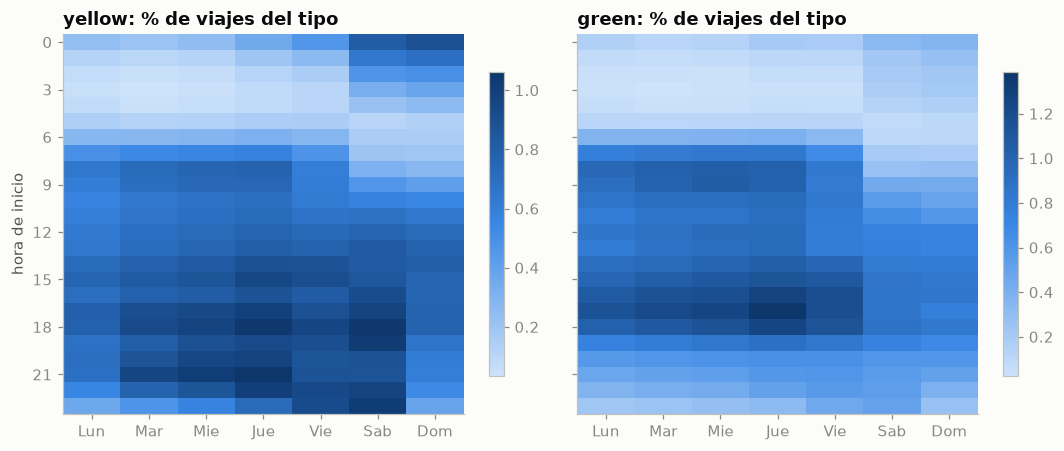

In [6]:
dias = ["Lun", "Mar", "Mie", "Jue", "Vie", "Sab", "Dom"]
fig, axes = plt.subplots(1, 2, figsize=(10, 4.2), sharey=True)
for ax, tipo in zip(axes, ["yellow", "green"]):
    m = df_hora[df_hora.tipo == tipo].pivot(index="hora", columns="dia_semana", values="pct_del_tipo")
    im = ax.imshow(m, aspect="auto", cmap=plt.matplotlib.colors.LinearSegmentedColormap.from_list(
        "azul", ["#cde2fb", "#3987e5", "#0d366b"]))
    ax.set_title(f"{tipo}: % de viajes del tipo")
    ax.set_xticks(range(7), dias)
    ax.set_yticks(range(0, 24, 3))
    ax.grid(False)
    fig.colorbar(im, ax=ax, shrink=0.8)
axes[0].set_ylabel("hora de inicio")
plt.tight_layout()

## 2. Caracteristicas de los viajes

### P3. Como se distribuyen distancia, duracion, monto y velocidad?

In [7]:
ejecutar("03_distribucion_viajes")

-- P3. Distribucion de distancia, duracion, monto total y velocidad por tipo
WITH metricas AS (
    SELECT tipo,
           trip_distance AS distancia_mi,
           duracion_min,
           total_amount AS total_usd,
           trip_distance / (duracion_min / 60) AS velocidad_mph
    FROM viajes_validos
), largo AS (
    UNPIVOT metricas
    ON distancia_mi, duracion_min, total_usd, velocidad_mph
    INTO NAME metrica VALUE valor
), resumen AS (
    SELECT tipo, metrica,
           avg(valor) AS promedio,
           quantile_cont(valor, [0.05, 0.25, 0.5, 0.75, 0.95, 0.99]) AS q,
           max(valor) AS maximo
    FROM largo
    GROUP BY ALL
)
SELECT tipo, metrica,
       round(promedio, 2) AS promedio,
       round(q[1], 2) AS p05, round(q[2], 2) AS p25, round(q[3], 2) AS mediana,
       round(q[4], 2) AS p75, round(q[5], 2) AS p95, round(q[6], 2) AS p99,
       round(maximo, 2) AS maximo
FROM resumen
ORDER BY metrica, tipo;



,tipo,metrica,promedio,p05,p25,mediana,p75,p95,p99,maximo
0,green,distancia_mi,3.36,0.63,1.33,2.15,3.78,10.67,17.81,134.49
1,yellow,distancia_mi,3.51,0.50,1.10,1.92,3.93,12.52,19.55,199.30
2,green,duracion_min,21.26,4.15,8.68,13.35,20.73,45.22,82.72,1439.80
3,yellow,duracion_min,17.95,4.02,8.62,14.12,22.27,44.13,71.70,1439.93
4,green,total_usd,25.54,9.70,15.12,20.52,29.70,56.84,96.00,1678.20
5,yellow,total_usd,30.20,12.40,17.45,23.58,34.43,77.20,104.96,7053.50
6,green,velocidad_mph,15.65,5.18,7.93,10.04,13.12,22.83,34.28,82272.00
7,yellow,velocidad_mph,11.10,3.94,6.83,9.28,12.93,24.11,34.46,68940.00


### P4. Como cambia la velocidad a lo largo del dia (lunes a viernes)?

In [8]:
df_vel = ejecutar("04_velocidad_por_hora")
df_vel

-- P4. Velocidad, duracion y distancia medianas por hora en dias laborales
SELECT tipo, hora,
       count(*) AS viajes,
       round(median(trip_distance / (duracion_min / 60)), 1) AS velocidad_mediana_mph,
       round(median(duracion_min), 1) AS duracion_mediana_min,
       round(median(trip_distance), 2) AS distancia_mediana_mi
FROM viajes_validos
WHERE dia_semana <= 5          -- lunes a viernes
  AND duracion_min >= 1        -- evita velocidades infladas por duraciones de segundos
GROUP BY ALL
ORDER BY tipo, hora;



,tipo,hora,viajes,velocidad_mediana_mph,duracion_mediana_min,distancia_mediana_mi
0,green,0,2503,12.6,11.0,2.24
1,green,1,1278,12.6,10.6,2.15
2,green,2,727,14.4,11.7,2.79
3,green,3,501,14.7,11.3,2.64
4,green,4,799,18.4,16.9,5.76
5,green,5,1881,16.1,15.7,4.96
6,green,6,5960,12.6,11.2,2.05
7,green,7,12617,10.2,13.0,2.04
8,green,8,15686,9.1,14.6,2.04
9,green,9,15475,9.4,14.5,2.18


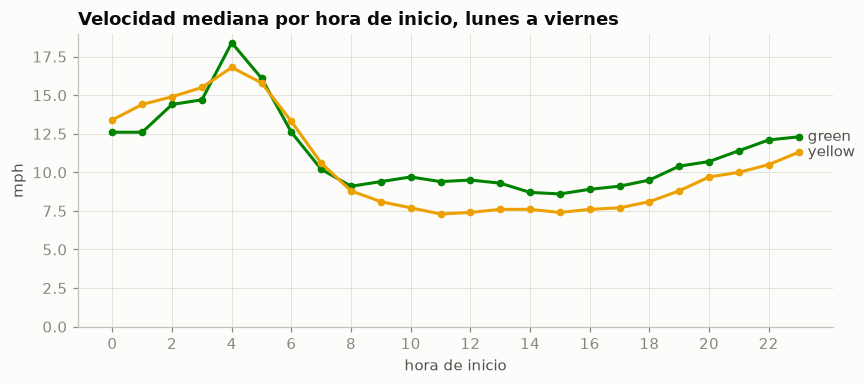

In [9]:
fig, ax = plt.subplots(figsize=(8, 3.6))
for tipo, g in df_vel.groupby("tipo"):
    ax.plot(g.hora, g.velocidad_mediana_mph, color=COLORES[tipo], marker="o", markersize=4)
    ax.annotate(tipo, (23, g.velocidad_mediana_mph.iloc[-1]), xytext=(6, 0),
                textcoords="offset points", va="center", color="#52514e")
ax.set_title("Velocidad mediana por hora de inicio, lunes a viernes")
ax.set_xlabel("hora de inicio")
ax.set_ylabel("mph")
ax.set_xticks(range(0, 24, 2))
ax.set_ylim(bottom=0)
plt.tight_layout()

### P5. Cuantos pasajeros lleva cada viaje?

In [10]:
ejecutar("05_pasajeros")

-- P5. Cantidad de pasajeros por viaje
SELECT tipo,
       CASE WHEN passenger_count IS NULL THEN 'sin dato'
            WHEN passenger_count >= 7 THEN '7+'
            ELSE passenger_count::VARCHAR END AS pasajeros,
       count(*) AS viajes,
       round(100 * count(*) / sum(count(*)) OVER (PARTITION BY tipo), 2) AS pct_del_tipo
FROM viajes_validos
GROUP BY tipo, pasajeros
ORDER BY tipo, pasajeros;



,tipo,pasajeros,viajes,pct_del_tipo
0,green,0,4266,1.32
1,green,1,228874,70.61
2,green,2,27504,8.48
3,green,3,3097,0.96
4,green,4,2253,0.70
5,green,5,6167,1.90
6,green,6,4243,1.31
7,green,7+,78,0.02
8,green,sin dato,47679,14.71
9,yellow,0,87523,0.31


## 3. Diferencias entre taxis amarillos y verdes

### P6. Donde se originan los viajes de cada tipo?

In [11]:
df_zonas = ejecutar("06_zonas_servicio")
df_zonas

-- P6. Donde se originan los viajes de cada tipo: borough y zona de servicio
SELECT v.tipo, z.borough, z.service_zone,
       count(*) AS viajes,
       round(100 * count(*) / sum(count(*)) OVER (PARTITION BY v.tipo), 2) AS pct_del_tipo
FROM viajes_validos v
JOIN zonas z ON v.PULocationID = z.LocationID
GROUP BY v.tipo, z.borough, z.service_zone
ORDER BY v.tipo, viajes DESC;



,tipo,borough,service_zone,viajes,pct_del_tipo
0,green,Manhattan,Boro Zone,170191,52.50
1,green,Queens,Boro Zone,71356,22.01
2,green,Brooklyn,Boro Zone,51268,15.82
3,green,Manhattan,Yellow Zone,22513,6.95
4,green,Bronx,Boro Zone,8067,2.49
5,green,Unknown,N/A,380,0.12
6,green,N/A,N/A,187,0.06
7,green,Queens,Airports,145,0.04
8,green,Staten Island,Boro Zone,54,0.02
9,yellow,Manhattan,Yellow Zone,23805652,83.23


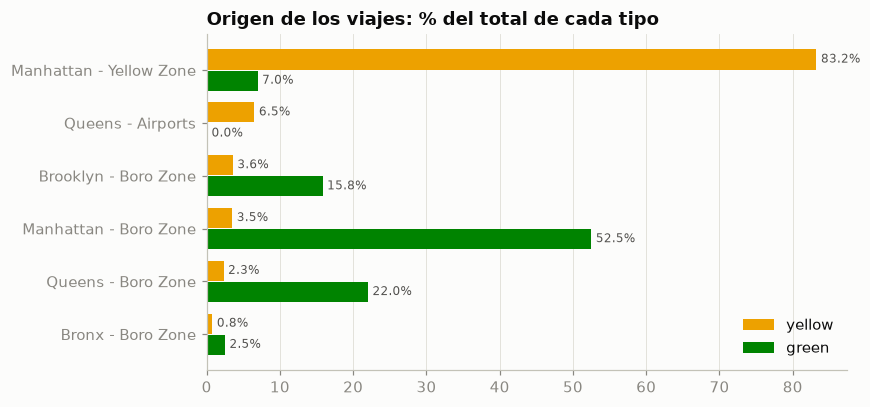

In [12]:
cat = (df_zonas.assign(categoria=lambda d: d.borough + " - " + d.service_zone)
       .pivot_table(index="categoria", columns="tipo", values="pct_del_tipo", fill_value=0))
cat = cat[cat.max(axis=1) >= 1].sort_values("yellow")
fig, ax = plt.subplots(figsize=(8, 3.8))
y = range(len(cat))
for i, tipo in enumerate(["yellow", "green"]):
    ax.barh([v + (0.2 if i == 0 else -0.2) for v in y], cat[tipo], height=0.38,
            color=COLORES[tipo], label=tipo)
    for v, val in zip(y, cat[tipo]):
        ax.annotate(f"{val:.1f}%", (val, v + (0.2 if i == 0 else -0.2)), xytext=(3, 0),
                    textcoords="offset points", va="center", fontsize=8, color="#52514e")
ax.set_yticks(list(y), cat.index)
ax.set_title("Origen de los viajes: % del total de cada tipo")
ax.legend(frameon=False, loc="lower right")
ax.grid(axis="y", visible=False)
plt.tight_layout()

### P7. Cuales son las zonas de origen mas frecuentes?

In [13]:
ejecutar("07_top_zonas")

-- P7. Las 10 zonas de origen con mas viajes por tipo de taxi
SELECT v.tipo,
       row_number() OVER (PARTITION BY v.tipo ORDER BY count(*) DESC) AS posicion,
       z.borough, z.zona, z.service_zone,
       count(*) AS viajes,
       round(100 * count(*) / sum(count(*)) OVER (PARTITION BY v.tipo), 2) AS pct_del_tipo
FROM viajes_validos v
JOIN zonas z ON v.PULocationID = z.LocationID
GROUP BY v.tipo, z.borough, z.zona, z.service_zone
QUALIFY posicion <= 10
ORDER BY v.tipo, posicion;



,tipo,posicion,borough,zona,service_zone,viajes,pct_del_tipo
0,green,1,Manhattan,East Harlem North,Boro Zone,87350,26.95
1,green,2,Manhattan,East Harlem South,Boro Zone,42023,12.96
2,green,3,Queens,Forest Hills,Boro Zone,15743,4.86
3,green,4,Manhattan,Central Park,Yellow Zone,13037,4.02
4,green,5,Manhattan,Morningside Heights,Boro Zone,12527,3.86
5,green,6,Queens,Elmhurst,Boro Zone,11250,3.47
6,green,7,Manhattan,Central Harlem,Boro Zone,11111,3.43
7,green,8,Brooklyn,Downtown Brooklyn/MetroTech,Boro Zone,10606,3.27
8,green,9,Queens,Jamaica,Boro Zone,9225,2.85
9,green,10,Brooklyn,Fort Greene,Boro Zone,8765,2.70


### P8. Cuanto pesan los viajes de aeropuerto?

In [14]:
ejecutar("08_aeropuertos")

-- P8. Peso y caracteristicas de los viajes que tocan un aeropuerto
-- Zonas: 132 = JFK, 138 = LaGuardia, 1 = Newark (EWR)
SELECT tipo,
       CASE WHEN 132 IN (PULocationID, DOLocationID) THEN 'JFK'
            WHEN 138 IN (PULocationID, DOLocationID) THEN 'LaGuardia'
            WHEN 1 IN (PULocationID, DOLocationID) THEN 'Newark'
            ELSE 'Sin aeropuerto' END AS aeropuerto,
       count(*) AS viajes,
       round(100 * count(*) / sum(count(*)) OVER (PARTITION BY tipo), 2) AS pct_viajes,
       round(100 * sum(total_amount) / sum(sum(total_amount)) OVER (PARTITION BY tipo), 2) AS pct_ingresos,
       round(median(trip_distance), 2) AS distancia_mediana_mi,
       round(median(duracion_min), 1) AS duracion_mediana_min,
       round(median(total_amount), 2) AS total_mediano
FROM viajes_validos
GROUP BY tipo, aeropuerto
ORDER BY tipo, viajes DESC;



,tipo,aeropuerto,viajes,pct_viajes,pct_ingresos,distancia_mediana_mi,duracion_mediana_min,total_mediano
0,green,Sin aeropuerto,313318,96.66,93.65,2.08,13.3,20.12
1,green,LaGuardia,8392,2.59,4.11,3.98,13.2,33.72
2,green,JFK,2286,0.71,1.95,14.27,38.2,73.45
3,green,Newark,165,0.05,0.29,21.56,44.8,143.76
4,yellow,Sin aeropuerto,26272026,91.85,78.96,1.77,13.3,22.39
5,yellow,JFK,1327469,4.64,12.51,16.90,41.5,89.21
6,yellow,LaGuardia,954839,3.34,7.78,9.50,28.9,69.96
7,yellow,Newark,49214,0.17,0.76,17.30,37.2,131.57


## 4. Variables de pago

### P9. Como se paga cada tipo de taxi?

In [15]:
df_pago = ejecutar("09_formas_de_pago")
df_pago

-- P9. Formas de pago: participacion en viajes e ingresos, y propinas registradas
SELECT tipo, forma_pago,
       count(*) AS viajes,
       round(100 * count(*) / sum(count(*)) OVER (PARTITION BY tipo), 2) AS pct_viajes,
       round(100 * sum(total_amount) / sum(sum(total_amount)) OVER (PARTITION BY tipo), 2) AS pct_ingresos,
       round(median(total_amount), 2) AS total_mediano,
       round(100 * avg((tip_amount > 0)::INT), 1) AS pct_con_propina
FROM viajes_validos
GROUP BY tipo, forma_pago
ORDER BY tipo, viajes DESC;



,tipo,forma_pago,viajes,pct_viajes,pct_ingresos,total_mediano,pct_con_propina
0,green,Tarjeta,212458,65.54,66.08,20.95,91.3
1,green,Efectivo,62921,19.41,16.05,16.10,0.0
2,green,Sin dato,47679,14.71,17.66,26.47,15.4
3,green,Sin cargo,774,0.24,0.15,7.30,0.3
4,green,Disputa,329,0.10,0.06,7.70,0.0
5,yellow,Tarjeta,18775408,65.64,65.15,22.35,91.2
6,yellow,Flex Fare,7044987,24.63,26.45,28.98,8.3
7,yellow,Efectivo,2603086,9.10,7.83,18.25,0.0
8,yellow,Disputa,120504,0.42,0.40,18.50,0.0
9,yellow,Sin cargo,59562,0.21,0.17,16.45,0.0


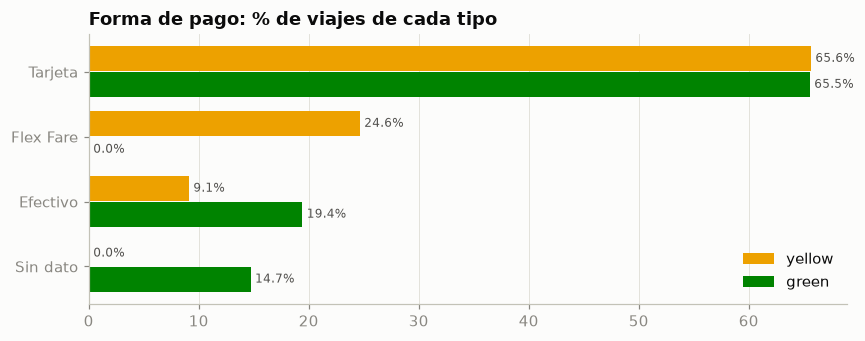

In [16]:
pv = df_pago.pivot_table(index="forma_pago", columns="tipo", values="pct_viajes", fill_value=0)
pv = pv[pv.max(axis=1) >= 0.5].sort_values("yellow")
fig, ax = plt.subplots(figsize=(8, 3.2))
y = range(len(pv))
for i, tipo in enumerate(["yellow", "green"]):
    pos = [v + (0.2 if i == 0 else -0.2) for v in y]
    ax.barh(pos, pv[tipo], height=0.38, color=COLORES[tipo], label=tipo)
    for p, val in zip(pos, pv[tipo]):
        ax.annotate(f"{val:.1f}%", (val, p), xytext=(3, 0), textcoords="offset points",
                    va="center", fontsize=8, color="#52514e")
ax.set_yticks(list(y), pv.index)
ax.set_title("Forma de pago: % de viajes de cada tipo")
ax.legend(frameon=False, loc="lower right")
ax.grid(axis="y", visible=False)
plt.tight_layout()

### P10. Como evoluciona el peso de Flex Fare en yellow?

In [17]:
ejecutar("10_flex_fare_mensual")

-- P10. Peso mensual de los viajes Flex Fare en yellow, por proveedor (VendorID)
SELECT anio, mes,
       count(*) AS viajes,
       round(100 * avg((payment_type = 0)::INT), 2) AS pct_flex,
       round(100 * avg((payment_type = 0)::INT) FILTER (WHERE VendorID = 1), 2) AS pct_flex_vendor1,
       round(100 * avg((payment_type = 0)::INT) FILTER (WHERE VendorID = 2), 2) AS pct_flex_vendor2,
       count(*) FILTER (WHERE VendorID = 6) AS viajes_vendor6,
       round(100 * avg((payment_type = 0)::INT) FILTER (WHERE VendorID = 6), 2) AS pct_flex_vendor6,
       count(*) FILTER (WHERE VendorID = 7) AS viajes_vendor7,
       round(100 * avg((payment_type = 0)::INT) FILTER (WHERE VendorID = 7), 2) AS pct_flex_vendor7
FROM viajes_validos
WHERE tipo = 'yellow'
GROUP BY ALL
ORDER BY anio, mes;



,anio,mes,viajes,pct_flex,pct_flex_vendor1,pct_flex_vendor2,viajes_vendor6,pct_flex_vendor6,viajes_vendor7,pct_flex_vendor7
0,2026,1,3561887,27.94,19.59,30.35,4016,100.0,43880,0.0
1,2026,2,3251330,28.58,19.86,30.99,5599,100.0,39680,0.0
2,2026,3,3811771,22.57,14.58,24.68,9454,100.0,47543,0.0
3,2026,4,3724338,19.89,13.26,21.65,9862,100.0,48643,0.0
4,2026,5,3964549,22.18,15.19,24.13,7642,100.0,50901,0.0
5,2026,6,3696434,24.97,18.71,26.39,8675,100.0,48625,0.0
6,2026,7,3388580,25.92,15.12,28.39,7486,100.0,41041,0.0
7,2026,8,3204659,26.19,15.00,28.85,6650,100.0,40061,0.0


### P11. De donde provienen los viajes Flex Fare? (junio a agosto)

In [18]:
ejecutar("11_flex_fare_origen")

-- P11. Origen de la solicitud (request_source) segun la forma de pago
-- request_source solo existe desde junio de 2026 (Ej. 3, consulta 07)
SELECT tipo, forma_pago,
       coalesce(request_source, 'NULL') AS request_source,
       count(*) AS viajes,
       round(100 * count(*) / sum(count(*)) OVER (PARTITION BY tipo, forma_pago), 2) AS pct_de_la_forma_pago
FROM viajes_validos
WHERE make_date(anio, mes, 1) >= DATE '2026-06-01'
GROUP BY tipo, forma_pago, request_source
HAVING count(*) >= 100
ORDER BY tipo, forma_pago, viajes DESC;



,tipo,forma_pago,request_source,viajes,pct_de_la_forma_pago
0,green,Disputa,NULL,123,100.00
1,green,Efectivo,NULL,22893,100.00
2,green,Sin cargo,NULL,268,100.00
3,green,Sin dato,A,17562,94.51
4,green,Sin dato,HV0005,1020,5.49
5,green,Tarjeta,NULL,79011,100.00
6,yellow,Disputa,NULL,33534,100.00
7,yellow,Efectivo,NULL,996471,100.00
8,yellow,Flex Fare,HV0003,2092429,79.25
9,yellow,Flex Fare,A,363694,13.77


### P12. Cuanta propina se deja en los pagos con tarjeta?

In [19]:
df_prop = ejecutar("12_propinas")
df_prop

-- P12. Distribucion de la propina (como % de la tarifa) en viajes pagados con tarjeta
WITH t AS (
    SELECT tipo, 100 * tip_amount / fare_amount AS pct_propina
    FROM viajes_validos
    WHERE payment_type = 1 AND fare_amount > 0
)
SELECT tipo,
       CASE WHEN pct_propina = 0 THEN '1. 0%'
            WHEN pct_propina < 10 THEN '2. (0, 10)'
            WHEN pct_propina < 15 THEN '3. [10, 15)'
            WHEN pct_propina < 20 THEN '4. [15, 20)'
            WHEN pct_propina < 25 THEN '5. [20, 25)'
            WHEN pct_propina < 30 THEN '6. [25, 30)'
            ELSE '7. 30% o mas' END AS rango_propina,
       count(*) AS viajes,
       round(100 * count(*) / sum(count(*)) OVER (PARTITION BY tipo), 2) AS pct_del_tipo
FROM t
GROUP BY tipo, rango_propina
ORDER BY tipo, rango_propina;



,tipo,rango_propina,viajes,pct_del_tipo
0,green,1. 0%,18408,8.66
1,green,"2. (0, 10)",11867,5.59
2,green,"3. [10, 15)",15415,7.26
3,green,"4. [15, 20)",13227,6.23
4,green,"5. [20, 25)",65722,30.93
5,green,"6. [25, 30)",50303,23.68
6,green,7. 30% o mas,37515,17.66
7,yellow,1. 0%,1650753,8.79
8,yellow,"2. (0, 10)",834919,4.45
9,yellow,"3. [10, 15)",1286205,6.85


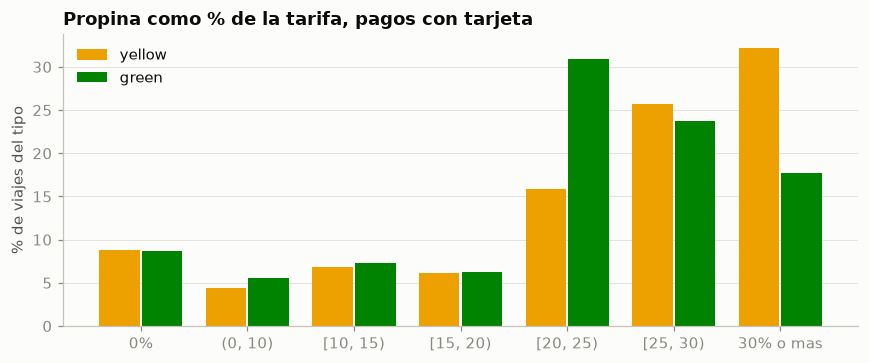

In [20]:
pv = df_prop.pivot(index="rango_propina", columns="tipo", values="pct_del_tipo")
etiquetas = [r.split(". ", 1)[1] for r in pv.index]
fig, ax = plt.subplots(figsize=(8, 3.4))
x = range(len(pv))
for i, tipo in enumerate(["yellow", "green"]):
    pos = [v + (-0.2 if i == 0 else 0.2) for v in x]
    ax.bar(pos, pv[tipo], width=0.38, color=COLORES[tipo], label=tipo)
ax.set_xticks(list(x), etiquetas)
ax.set_title("Propina como % de la tarifa, pagos con tarjeta")
ax.set_ylabel("% de viajes del tipo")
ax.legend(frameon=False)
ax.grid(axis="x", visible=False)
plt.tight_layout()

## 5. Valores atipicos e inconsistencias

### P13. Cuadra el monto total con la suma de sus componentes?

In [21]:
ejecutar("13_consistencia_montos")

-- P13. Cuadra total_amount con la suma de sus componentes?
-- Se prueban dos formulas: con y sin congestion_surcharge y cbd_congestion_fee.
WITH d AS (
    SELECT tipo, VendorID, coalesce(payment_type = 0, false) AS es_flex, extra,
           fare_amount + extra + mta_tax + tip_amount + tolls_amount + improvement_surcharge
               + coalesce(Airport_fee, 0) + coalesce(ehail_fee, 0) AS base,
           coalesce(congestion_surcharge, 0) + coalesce(cbd_congestion_fee, 0) AS recargos_congestion,
           total_amount
    FROM viajes_validos
)
SELECT tipo, VendorID, es_flex,
       count(*) AS viajes,
       round(100 * avg((abs(total_amount - base - recargos_congestion) <= 0.01)::INT), 1) AS pct_cuadra_con_recargos,
       round(100 * avg((abs(total_amount - base) <= 0.01)::INT), 1) AS pct_cuadra_sin_recargos,
       round(avg(extra), 2) AS extra_promedio,
       round(avg(recargos_congestion), 2) AS recargos_promedio
FROM d
GROUP BY ALL
HAVING count(*) >= 100
ORDER BY tipo, Vend

,tipo,VendorID,es_flex,viajes,pct_cuadra_con_recargos,pct_cuadra_sin_recargos,extra_promedio,recargos_promedio
0,green,1,False,27000,3.2,4.4,1.88,1.06
1,green,2,False,262319,98.4,67.1,0.84,0.93
2,green,6,False,34842,0.0,0.0,0.00,0.01
3,yellow,1,False,4499053,16.3,94.7,3.41,2.51
4,yellow,1,True,877431,1.4,1.4,0.16,0.51
5,yellow,2,False,16699134,99.9,6.8,1.04,2.88
6,yellow,2,True,6108172,12.0,11.8,0.00,0.54
7,yellow,6,True,59384,0.0,0.0,0.00,0.01
8,yellow,7,False,360374,57.1,2.6,0.00,2.91


### P14. Cuantos registros excluyen las reglas de calidad?

In [22]:
ejecutar("14_registros_excluidos")

-- P14. Cuantos registros incumplen cada regla de calidad y cuantos se excluyen en total
-- Un registro puede incumplir varias reglas, por eso las columnas no suman el total.
SELECT tipo,
       count(*) AS registros,
       count(*) FILTER (WHERE NOT ok_fecha) AS fecha_fuera_del_mes,
       count(*) FILTER (WHERE NOT ok_duracion) AS duracion_invalida,
       count(*) FILTER (WHERE NOT ok_distancia) AS distancia_invalida,
       count(*) FILTER (WHERE NOT ok_monto) AS monto_negativo,
       count(*) FILTER (WHERE NOT (ok_fecha AND ok_duracion AND ok_distancia AND ok_monto)) AS excluidos,
       round(100 * count(*) FILTER (WHERE NOT (ok_fecha AND ok_duracion AND ok_distancia AND ok_monto))
             / count(*), 2) AS pct_excluidos
FROM viajes
GROUP BY tipo
ORDER BY tipo;



,tipo,registros,fecha_fuera_del_mes,duracion_invalida,distancia_invalida,monto_negativo,excluidos,pct_excluidos
0,green,337114,98,238,12281,1025,12953,3.84
1,yellow,29703355,146,4826,952935,161970,1099807,3.70


### P15. Que valores son atipicos dentro de los viajes validos?

In [23]:
ejecutar("15_atipicos_iqr")

-- P15. Valores atipicos por la regla de Tukey (Q3 + 1.5 * IQR) sobre los viajes validos
WITH metricas AS (
    SELECT tipo,
           trip_distance AS distancia_mi,
           duracion_min,
           total_amount AS total_usd,
           trip_distance / (duracion_min / 60) AS velocidad_mph
    FROM viajes_validos
), cuartiles AS (           -- una fila por tipo: [Q1, Q3] de cada metrica
    SELECT tipo,
           quantile_cont(distancia_mi, [0.25, 0.75]) AS q_distancia_mi,
           quantile_cont(duracion_min, [0.25, 0.75]) AS q_duracion_min,
           quantile_cont(total_usd, [0.25, 0.75]) AS q_total_usd,
           quantile_cont(velocidad_mph, [0.25, 0.75]) AS q_velocidad_mph
    FROM metricas
    GROUP BY tipo
), limites AS (             -- limite superior de Tukey por tipo y metrica
    SELECT tipo,
           q_distancia_mi[2] + 1.5 * (q_distancia_mi[2] - q_distancia_mi[1]) AS lim_distancia_mi,
           q_duracion_min[2] + 1.5 * (q_duracion_min[2] - q_duracion_min[1]) AS l

,tipo,metrica,q1,q3,limite_superior,atipicos,pct_atipicos,maximo,mas_de_80_mph
0,green,distancia_mi,1.33,3.78,7.46,33000,10.18,134.49,<NA>
1,yellow,distancia_mi,1.10,3.93,8.18,3143401,10.99,199.30,<NA>
2,green,duracion_min,8.68,20.73,38.81,23028,7.10,1439.80,<NA>
3,yellow,duracion_min,8.62,22.27,42.74,1534511,5.36,1439.93,<NA>
4,green,total_usd,15.12,29.70,51.57,21581,6.66,1678.20,<NA>
5,yellow,total_usd,17.45,34.43,59.90,2444058,8.54,7053.50,<NA>
6,green,velocidad_mph,7.93,13.12,20.89,22001,6.79,82272.00,1087
7,yellow,velocidad_mph,6.83,12.93,22.08,1873306,6.55,68940.00,7294


### P16. Que proveedores generan los viajes con duracion cero?

In [24]:
ejecutar("16_duracion_cero_vendor")

-- P16. Que proveedores generan los viajes con duracion cero (dropoff = pickup)?
-- Se consulta la vista viajes (sin filtrar) para ver todos los registros.
SELECT tipo, VendorID,
       count(*) AS registros,
       count(*) FILTER (WHERE dropoff = pickup) AS duracion_cero,
       round(100 * count(*) FILTER (WHERE dropoff = pickup) / count(*), 2) AS pct_duracion_cero,
       round(100 * count(*) FILTER (WHERE dropoff = pickup) / sum(count(*) FILTER (WHERE dropoff = pickup)) OVER (PARTITION BY tipo), 2) AS pct_del_total_cero,
       round(median(trip_distance) FILTER (WHERE dropoff = pickup), 2) AS distancia_mediana_cero,
       round(median(fare_amount) FILTER (WHERE dropoff = pickup), 2) AS tarifa_mediana_cero
FROM viajes
GROUP BY tipo, VendorID
ORDER BY tipo, VendorID;



,tipo,VendorID,registros,duracion_cero,pct_duracion_cero,pct_del_total_cero,distancia_mediana_cero,tarifa_mediana_cero
0,green,1,28696,86,0.30,37.55,0.00,7.90
1,green,2,273571,143,0.05,62.45,0.00,10.00
2,green,6,34847,0,0.00,0.00,NaN,NaN
3,yellow,1,5467071,4297,0.08,1.16,0.00,10.12
4,yellow,2,23809774,256,0.00,0.07,0.00,18.98
5,yellow,6,59390,0,0.00,0.00,NaN,NaN
6,yellow,7,367120,367120,100.00,98.77,1.51,12.10


### P17. Los viajes de 3 a 6 pasajeros en green se comportan como viajes de grupo?

In [25]:
ejecutar("17_pasajeros_por_vendor")

-- P17. Los viajes de 3 a 6 pasajeros en green se comportan como viajes de grupo?
SELECT VendorID, passenger_count,
       count(*) AS viajes,
       round(median(trip_distance), 2) AS distancia_mediana_mi,
       round(median(total_amount), 2) AS total_mediano
FROM viajes_validos
WHERE tipo = 'green' AND passenger_count BETWEEN 3 AND 6
GROUP BY VendorID, passenger_count
ORDER BY VendorID, passenger_count;



,VendorID,passenger_count,viajes,distancia_mediana_mi,total_mediano
0,1,3,607,2.10,20.90
1,1,4,149,2.50,23.05
2,1,5,19,2.10,19.60
3,1,6,8,2.20,20.90
4,2,3,2490,2.09,21.30
5,2,4,2104,2.98,35.00
6,2,5,6148,1.85,19.20
7,2,6,4235,1.68,18.10
